# **Evaluating Classification Models**

### Objectives
* Implement and evaluate the performance of classification models on real-world data
* Interpret and compare various metrics and the confusion matrix for each model

### Introduction
We will use the breast cancer data set included in scikit-learn to predict whether a tumor is benign or malignant. We will create two classification models and evaluate them, and add some Gaussian random noise to the features to simulate measurement errors.

Interpreting and comparing the various evaluation metrics and the confusion matrix for each model will provide you with some valuable intuition regarding what the evaluation metrics mean and how they might impact your interpretation of the model performances.

The goal here id not to find the best classifier - it is primarily intended for practice interpreting and comparing results in the context of a real-world problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer data set
data = load_breast_cancer()
X = data.data
y = data.target
labels = data.target_names
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
print(data.target_names)

['malignant' 'benign']


#### Standardize the data

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Add some noise
Add some noise to simulate random measurement error, then view the first few rows of the original and noisy features for comparison.

In [6]:
# Add Gaussian noise to the features
np.random.seed(42)
noise_factor = 0.5 # Adjust this to control the amount of noise
X_noisy = X_scaled + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_scaled.shape)

# Load the original and noisy data sets into a DataFrame for comparison and visualization
df = pd.DataFrame(X_scaled, columns = feature_names)
df_noisy = pd.DataFrame(X_noisy, columns = feature_names)

#### Visualizing the noise content

We can get a good idea of how much noise there is in the features by comparing values in the previous tables. We can also visualize the differences in several ways.

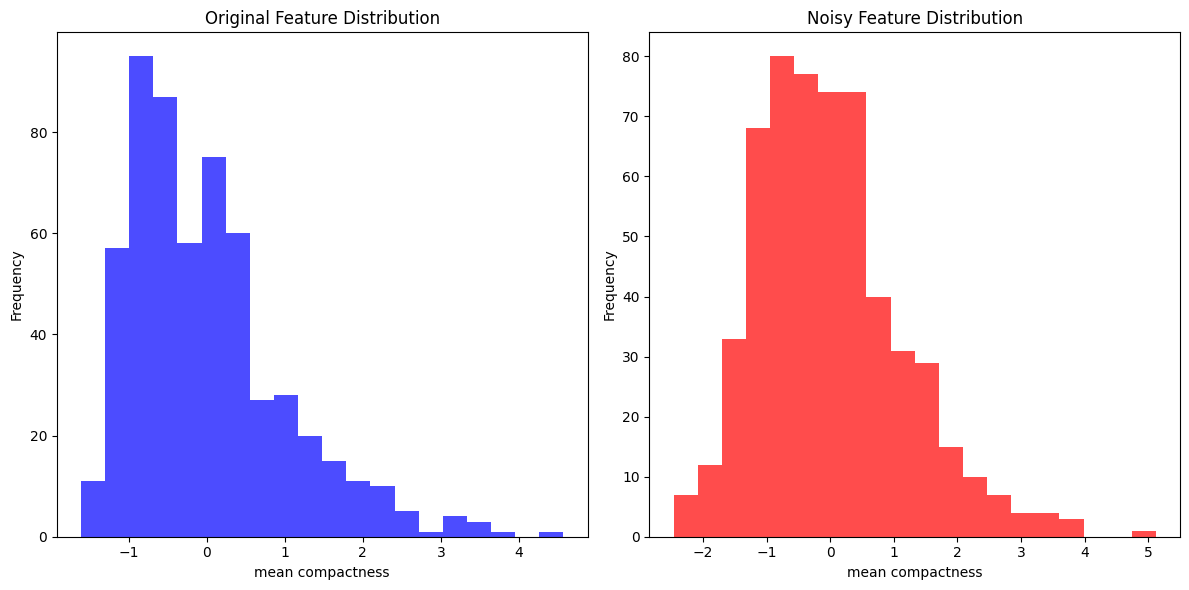

In [7]:
# HISTOGRAM
plt.figure(figsize=(12, 6))

# Orignial Feature Distribution (Noise-Free)
plt.subplot(1, 2, 1)
plt.hist(df[feature_names[5]], bins=20, alpha=0.7, color='blue', label='Original')
plt.title("Original Feature Distribution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")

# Noisy Feature Distribution
plt.subplot(1, 2, 2)
plt.hist(df_noisy[feature_names[5]], bins=20, alpha=0.7, color='red', label='Noisy')
plt.title("Noisy Feature Distribution")
plt.xlabel(feature_names[5])
plt.ylabel("Frequency")

plt.tight_layout()  # Ensures proper spacing between subplots
plt.show()

The noise-free histogram is skewed to the left and appears to a log-normal distribution, while the noisy histogram is less skewed, tending toward a normal distribution.

#### Plots

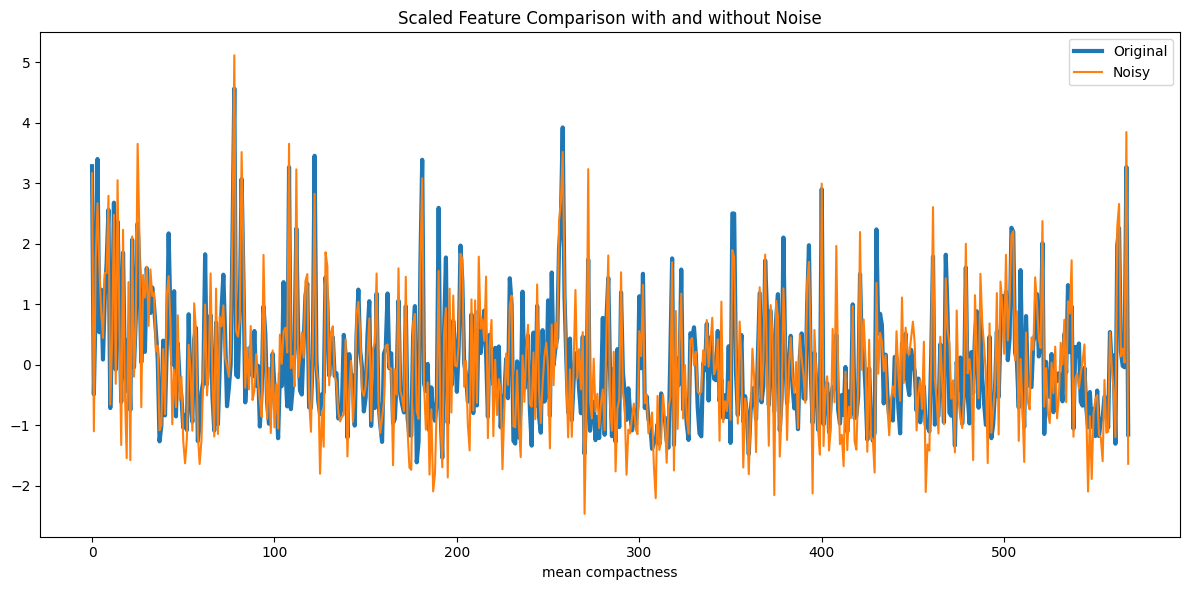

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df[feature_names[5]], label='Original', lw=3)
plt.plot(df_noisy[feature_names[5]], label='Noisy')
plt.title("Scaled Feature Comparison with and without Noise")
plt.xlabel(feature_names[5])
plt.legend()
plt.tight_layout()
plt.show()

#### Scatterplot

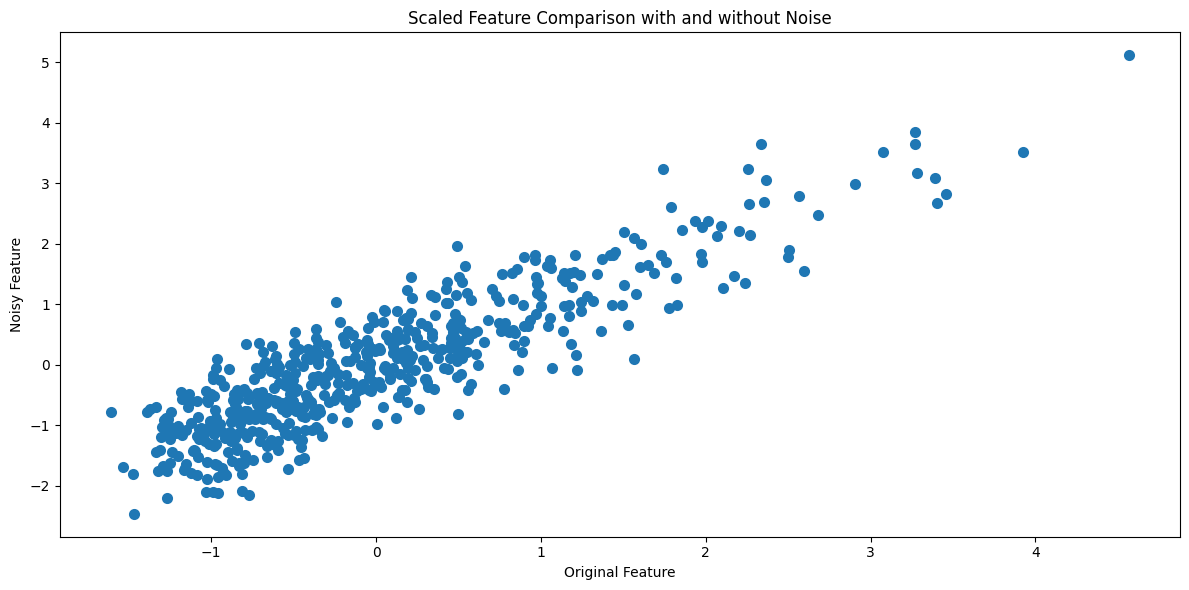

In [9]:
plt.figure(figsize=(12,6))
plt.scatter(df[feature_names[5]], df_noisy[feature_names[5]], lw=2)
plt.title("Scaled Feature Comparison with and without Noise")
plt.xlabel("Original Feature")
plt.ylabel("Noisy Feature")
plt.tight_layout()
plt.show()

#### Split the data, and fit the KNN and SVM models to the noisy training data

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Split the data set into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the models
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='linear', C=1, random_state=42)

# Fit the models to the training data
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Evaluate the models

#### Predict on the test set

In [25]:
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

#### Print the accuracy scores and classification reports for both models

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"KNN Testing Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"SVM Testing Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")

print("\nKNN Testing Data Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=labels))

print("\nSVM Testing Data Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=labels))

KNN Testing Accuracy: 0.956
SVM Testing Accuracy: 0.974

KNN Testing Data Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM Testing Data Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### Plot the Confusion Matrices

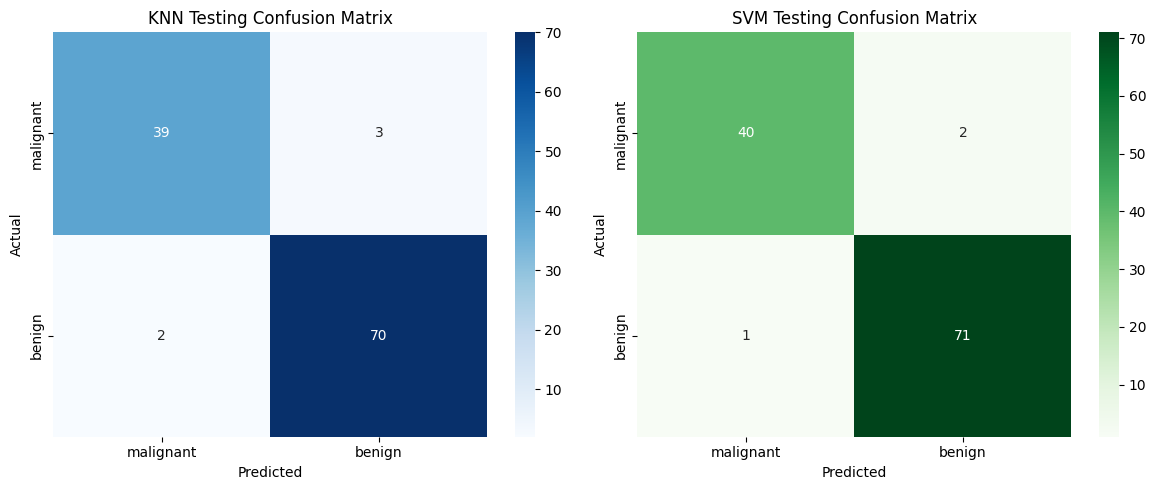

In [27]:
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("KNN Testing Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("SVM Testing Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### What is the worst kind of prediction error in this context?
By convention, a positive test for malignancy means a diagnosis of a mass being malignant. Thus, a benign prediction is negative prediction. The worse-case scenario then is a false negative prediction, where the test incorrectly predicts that the mass is benign.
For the KNN model, the number of false negatives is 7, while for the SVM model the count is 2. We can say that the SVM model has a higher prediction sensitivity than the KNN model does.

#### What can we say to compare the overall performances of the two models?
SVM outperformed KNN in terms of precision, recall, and F1-score for both for the individual classes and their overall averages. This indicates that SVM is a stronger classifier. Although KNN performed quite well with an accuracy of 94%, SVM has better ability to correctly classify both malignant and beinign cases, with fewer errors. Given that the goal would be to choose the model with better generalization and fewer false negatives, SVM is certainly the preferred classifier.

#### Are we overfitting?
We can evaluate the results on the training data and compare them against the test data results

In [28]:
y_pred_train_knn = knn.predict(X_train)
y_pred_train_svm = svm.predict(X_train)

In [30]:
print(f"KNN Training Accuracy: {accuracy_score(y_train, y_pred_train_knn):.2%}")
print(f"SVM Training Accuracy: {accuracy_score(y_train, y_pred_train_svm):.2%}")

print("\nKNN Training Classification Report:")
print(classification_report(y_train, y_pred_train_knn, target_names=labels))

print("\nSVM Training Classification Report:")
print(classification_report(y_train, y_pred_train_svm, target_names=labels))

KNN Training Accuracy: 95.38%
SVM Training Accuracy: 97.80%

KNN Training Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.92      0.94       170
      benign       0.96      0.97      0.96       285

    accuracy                           0.95       455
   macro avg       0.95      0.95      0.95       455
weighted avg       0.95      0.95      0.95       455


SVM Training Classification Report:
              precision    recall  f1-score   support

   malignant       0.99      0.95      0.97       170
      benign       0.97      1.00      0.98       285

    accuracy                           0.98       455
   macro avg       0.98      0.97      0.98       455
weighted avg       0.98      0.98      0.98       455



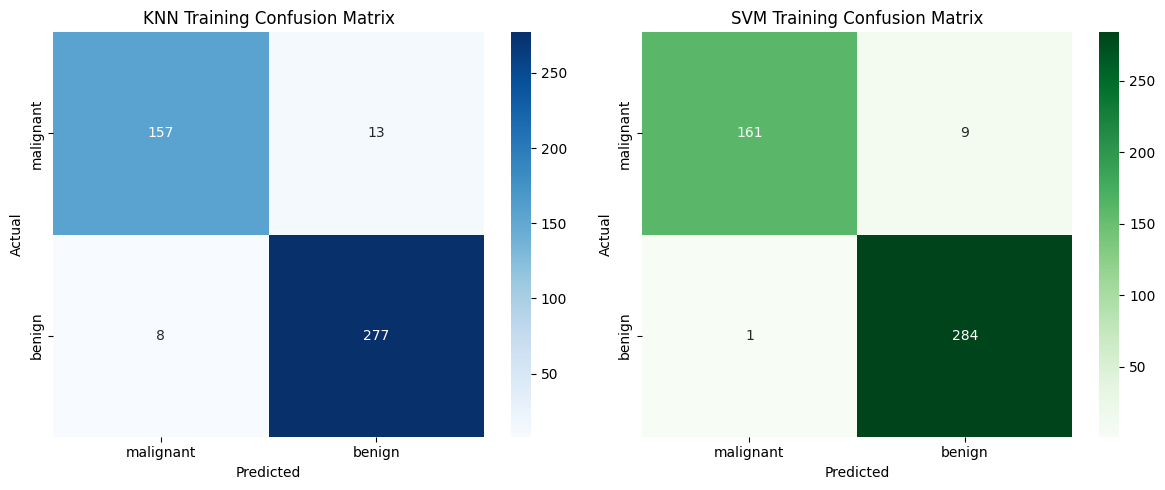

In [31]:
conf_matrix_knn_train = confusion_matrix(y_train, y_pred_train_knn)
conf_matrix_svm_train = confusion_matrix(y_train, y_pred_train_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_knn_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("KNN Training Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(conf_matrix_svm_train, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("SVM Training Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### Creating the Learning Curve

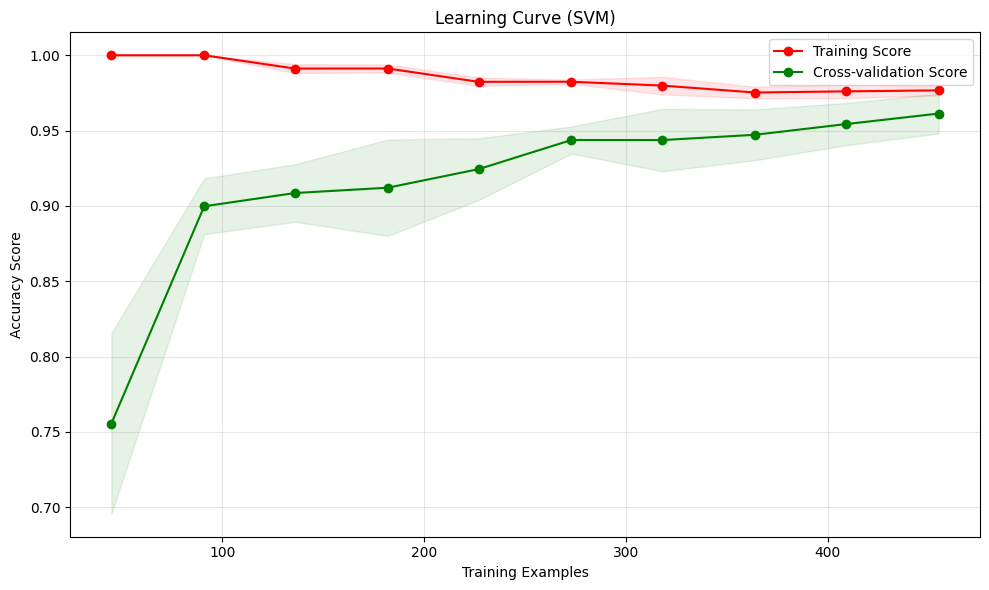

In [32]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )

    # Calculate mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plotting
    plt.figure(figsize=(10,6))
    plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation Score')

    # Add shadow for variance (Standard Deviation)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color='g')
    
    plt.title("Learning Curve (SVM)")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the function
plot_learning_curve(svm, X_noisy, y)

#### Cross-validation Check


In [37]:
from sklearn.model_selection import cross_val_score

# run 10 -fold Cross-Validation
# We use the whole dataset (X, y) becuase the function handles the splitting
cv_scores_svm = cross_val_score(svm, X_noisy, y, cv=10, n_jobs=-1)

print("SVM Cross-Validation Results")
print(f"Scores for each fold: \n{cv_scores_svm}")
print(f"\nAverage CV Accuracy: {cv_scores_svm.mean():.4f}")
print(f"Standard Deviation: {cv_scores_svm.std():.4f}")

print('-' * 50)

cv_scores_knn = cross_val_score(knn, X_noisy, y, cv=10, n_jobs=-1)

print("KNN Cross-Validation Results")
print(f"Scores for each fold: \n{cv_scores_knn}")
print(f"\nAverage CV Accuracy: {cv_scores_knn.mean():.4f}")
print(f"Standard Deviation: {cv_scores_knn.std():.4f}")

SVM Cross-Validation Results
Scores for each fold: 
[0.98245614 0.94736842 0.92982456 0.96491228 1.         0.94736842
 0.94736842 0.92982456 0.96491228 0.94642857]

Average CV Accuracy: 0.9560
Standard Deviation: 0.0212
--------------------------------------------------
KNN Cross-Validation Results
Scores for each fold: 
[0.94736842 0.94736842 0.94736842 0.92982456 0.94736842 0.92982456
 0.89473684 0.94736842 0.92982456 0.94642857]

Average CV Accuracy: 0.9367
Standard Deviation: 0.0160


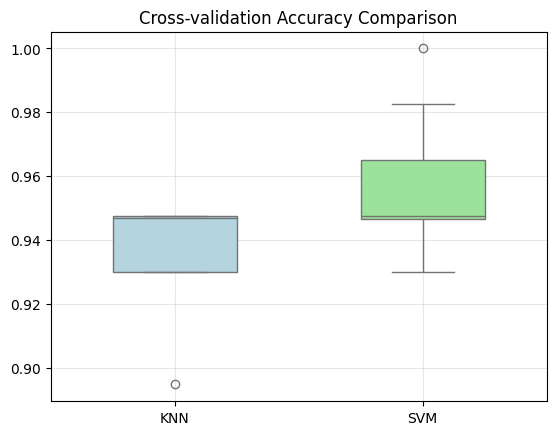

In [52]:
# BOX PLOT
sns.boxplot([cv_scores_knn, cv_scores_svm], palette=["lightblue", "lightgreen"], 
            width=0.5)
plt.xticks([0,1], ['KNN', 'SVM'])
plt.title("Cross-validation Accuracy Comparison")
plt.grid(alpha=0.3)
plt.show()

Ideally the accuracy of a model would be almost the same on the training and testing data sets.

It would be unusual for the accuracy to be higher on the test set and this might occur due to chance or some sort of data leakage. For example, here we have normalized all of the data rather than fitting StandardScaler to the training data and only then applying it to the train and test sets separately.

When the accuracy is substantially higher on the training data than on the testing data, the model is likely memorizing details in the training data that don't generalize to the unseen data - the model is overfitting to the training data.

| Model | Phase |  Accuracy |
| ------------  | -------- | --------- |
| KNN  | Train  | 95.5% |
| KNN  | Test   | 93.6% |
| SVM  | Train  | 97.2% |
| SVM  | Test   | 97.1% |


For the SVM model, the training and testing accuracies are essentially the same at about 97%. This is ideal - the SVM model is likely not overfit. For the KNN model, however, the training accuracy is about 2% higher that the test accuracy, indicating there might be some overfitting.

In summary, the SVM model is both more convincing and has a higher accuracy than the KNN model. Remember, we aren't trying to tune these models; we are just comparing their performance with a fixed set of hyperparameters.